# Rapport EDA — Couverture médiatique Crypto (Bitcoin)

**Date :** Mars 2026  
**Pipeline :** GDELT — Bronze → Silver → Gold  
**Auteur :** crypto-prediction project  

---

## Contexte et objectif

Ce rapport analyse la couverture médiatique de **Bitcoin** issue de la base GDELT, structurée en trois couches de données :
- **Bronze** : articles bruts (URL, dates, domaines)
- **Silver** : articles nettoyés et filtrés par monnaie
- **Gold** : agrégation journalière par source média, enrichie du signal de tonalité (`avg_tone`)

L'objectif final est de **qualifier la donnée médiatique comme signal d'entrée pour un modèle ML de prédiction de prix**. Ce notebook constitue le livrable EDA principal.

---

## Plan du rapport

| # | Section | Contenu |
|---|---------|---------|
| 1 | **Initialisation** | Imports, chemins, configuration |
| 2 | **Chargement des données** | Lecture Bronze / Silver / Gold, shapes et schémas |
| 3 | **Contrôle qualité** | Valeurs manquantes, doublons, couverture domaine |
| 4 | **EDA Gold** | Volume journalier, statistiques, jours atypiques (z-score) |
| 5 | **Tendances temporelles** | Séries chronologiques, moyennes mobiles 7j / 30j |
| 6 | **KPI de couverture** | Résumé chiffrable prêt pour présentation |
| 7 | **Pondération des sources** | Classification (trusted / crypto / other) et coefficients |
| 8 | **Préparation ML** | Lissage 3 jours, gold pondéré, exports CSV |
| 9 | **Visualisations comparatives** | Raw vs Weighted, séries lissées (Plotly) |
| 10 | **Analyse de corrélation** | Heatmap Pearson & Spearman — tone vs count |
| 11 | **Analyse Lead-Lag** | Décalage temporel avg_tone → volume d'articles |
| 12 | **Conclusion** | Enseignements clés et recommandations ML |

In [ ]:
# =============================================================================
# SECTION 1 — Initialisation
# -----------------------------------------------------------------------------
# Imports, options pandas et résolution du répertoire racine du projet.
# Le script remonte d'un niveau si le dossier 'data/' n'est pas trouvé dans
# le répertoire courant (cas d'un lancement depuis notebooks/).
# =============================================================================
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

BASE_DIR = Path.cwd()
if not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
BRONZE_PATH = DATA_DIR / "bronze" / "bitcoin_bronze.jsonl"
SILVER_PATH = DATA_DIR / "silver" / "bitcoin_silver.csv"
GOLD_PATH = DATA_DIR / "gold" / "bitcoin_gold.csv"

print("BASE_DIR:", BASE_DIR)
print("BRONZE:", BRONZE_PATH)
print("SILVER:", SILVER_PATH)
print("GOLD:", GOLD_PATH)

BASE_DIR: /home/herrahj/test_crypto/crypto-prediction
BRONZE: /home/herrahj/test_crypto/crypto-prediction/data/bronze/bitcoin_bronze.jsonl
SILVER: /home/herrahj/test_crypto/crypto-prediction/data/silver/bitcoin_silver.csv
GOLD: /home/herrahj/test_crypto/crypto-prediction/data/gold/bitcoin_gold.csv


In [ ]:
# =============================================================================
# SECTION 2 — Chargement des données
# -----------------------------------------------------------------------------
# Lecture des trois couches de la pipeline :
#   - bronze (JSONL)  : articles bruts issus de GDELT
#   - silver (CSV)    : articles nettoyés, filtrés et enrichis
#   - gold   (CSV)    : agrégation journalière par source media (pivot)
# Contrôle visuel : shapes, colonnes, plages temporelles et aperçu des données.
# =============================================================================
bronze_df = pd.read_json(BRONZE_PATH, lines=True)
silver_df = pd.read_csv(SILVER_PATH)
gold_df = pd.read_csv(GOLD_PATH)

# Conversion des dates pour faciliter les analyses temporelles
silver_df["date"] = pd.to_datetime(silver_df["date"], errors="coerce")
gold_df["date"] = pd.to_datetime(gold_df["date"], errors="coerce")

print("Shapes:")
print("- bronze:", bronze_df.shape)
print("- silver:", silver_df.shape)
print("- gold  :", gold_df.shape)

print("\nColonnes:")
print("- bronze:", list(bronze_df.columns))
print("- silver:", list(silver_df.columns))
print("- gold  :", list(gold_df.columns))

print("\nPerimetre temporel:")
print("- silver:", silver_df["date"].min(), "->", silver_df["date"].max())
print("- gold  :", gold_df["date"].min(), "->", gold_df["date"].max())

print("\nApercu:")
display(bronze_df.head(2))
display(silver_df.head(2))
display(gold_df.head(2))

Shapes:
- bronze: (4023242, 3)
- silver: (4018370, 3)
- gold  : (4035, 18)

Colonnes:
- bronze: ['url', 'seendate', 'domain']
- silver: ['date', 'url', 'domain']
- gold  : ['date', 'BBC', 'Bitcoin.com', 'Bloomberg', 'CNN', 'CoinDesk', 'CoinSpeaker', 'Cointelegraph', 'Decrypt', 'Financial Times', 'France 24', 'Le Figaro', 'Le Monde', 'Les Échos', 'New York Times', 'Other', 'Reuters', 'total']

Perimetre temporel:
- silver: 2015-02-18 00:00:00 -> 2026-03-24 00:00:00
- gold  : 2015-02-18 00:00:00 -> 2026-03-24 00:00:00

Apercu:


,url,seendate,domain
0,https://news.bitcoin.com/over-200-venezuelan-t...,2019-10-10,news.bitcoin.com
1,https://www.edaily.co.kr/news/read?newsId=0218...,2019-10-10,edaily.co.kr


,date,url,domain
0,2019-10-10,https://news.bitcoin.com/over-200-venezuelan-t...,news.bitcoin.com
1,2019-10-10,https://www.edaily.co.kr/news/read?newsId=0218...,edaily.co.kr


,date,BBC,Bitcoin.com,Bloomberg,CNN,CoinDesk,CoinSpeaker,Cointelegraph,Decrypt,Financial Times,France 24,Le Figaro,Le Monde,Les Échos,New York Times,Other,Reuters,total
0,2015-02-18,0,0,0,1,0,0,0,0,0,0,0,0,0,0,38,0,39
1,2015-02-19,0,0,1,1,7,0,1,0,0,0,0,0,0,2,198,1,211


## 3 — Contrôle qualité Bronze / Silver

Avant de travailler sur le Gold, on vérifie l'intégrité des deux couches amont :

- **Bronze** : taux de champs critiques manquants (`url`, `seendate`, `domain`)
- **Silver** : doublons d'URL (signe de dédoublonnage incomplet) et dates invalides
- **Couverture domaine** : top 20 des sources pour valider la représentativité de la collecte

> **Critère de qualité acceptable** : taux de manquants < 5 % sur les champs clés, duplication URL < 1 %.

In [ ]:
# =============================================================================
# SECTION 3 — Contrôle qualité Bronze / Silver
# -----------------------------------------------------------------------------
# Bronze : taux de valeurs manquantes sur les champs critiques (url, seendate, domain)
# Silver : détection de doublons d'URL et de dates invalides
# Silver : top 20 des domaines pour valider la diversité de couverture
# =============================================================================

# Bronze: champs manquants
bronze_missing = bronze_df[["url", "seendate", "domain"]].isna().mean().sort_values(ascending=False)
print("Taux de valeurs manquantes - bronze")
display((bronze_missing * 100).round(2).to_frame("missing_pct"))

# Silver: duplications URL + dates nulles
silver_url_dupes = silver_df["url"].duplicated().sum()
silver_date_na = silver_df["date"].isna().sum()
print("Duplicats URL silver:", silver_url_dupes)
print("Dates invalides/nan silver:", silver_date_na)

# Domaines les plus frequents
print("\nTop 20 domaines silver")
display(silver_df["domain"].value_counts(dropna=False).head(20).to_frame("count"))

Taux de valeurs manquantes - bronze


,missing_pct
url,0.0
seendate,0.0
domain,0.0


Duplicats URL silver: 0
Dates invalides/nan silver: 0

Top 20 domaines silver


,count
domain,
dailypolitical.com,131464
wkrb13.com,127247
modernreaders.com,111508
biztoc.com,98489
themarketsdaily.com,76285
theenterpriseleader.com,58465
newsbtc.com,56580
tickerreport.com,40366
insidebitcoins.com,38303


## 4–6 — EDA Gold (focus principal)

Le Gold est la couche de référence : une ligne par jour, une colonne par source média.  
Cette section couvre trois analyses complémentaires :

**4. Statistiques et concentration des sources**  
Distribution du volume journalier, ranking des sources, indice de concentration (part cumulée top-N).

**5. Tendances temporelles**  
Séries chronologiques du volume total avec moyennes mobiles 7j et 30j pour lisser le bruit, plus décomposition par source (top 6).

**6. KPI de couverture (résumé livrable)**  
Tableau de bord synthétique : nombre de jours, articles totaux, médiane journalière, percentile 90, part des top sources.

> **Indicateur clé à surveiller** : les jours avec |z-score| ≥ 3 correspondent à des événements médiatiques majeurs (bull run, crash, régulation) — utiles comme features événementielles pour le ML.

In [ ]:
# =============================================================================
# SECTION 4 — Statistiques Gold : volume, sources et jours atypiques
# -----------------------------------------------------------------------------
# - Distribution statistique du volume journalier total (percentiles étendus)
# - Ranking cumulé des sources sur toute la période (concentration)
# - Détection des jours atypiques via z-score (|z| >= 3 = événement exceptionnel)
# =============================================================================

# Identification des colonnes sources (tout sauf date et total)
non_source_cols = {"date", "total"}
source_cols = [c for c in gold_df.columns if c not in non_source_cols]

# Qualite et stats globales
print("Nombre de jours:", len(gold_df))
print("Nombre de sources:", len(source_cols))
print("Total articles (somme total):", int(gold_df["total"].sum()))
print("Volume journalier - stats:")
display(gold_df["total"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("total"))

# Top sources sur toute la periode
source_totals = gold_df[source_cols].sum().sort_values(ascending=False)
print("\nTop 15 sources (volume cumule)")
display(source_totals.head(15).to_frame("articles"))

# Concentration des sources (part cumulee)
source_share = (source_totals / source_totals.sum()).rename("share")
source_share_cum = source_share.cumsum().rename("cum_share")
concentration_df = pd.concat([source_share, source_share_cum], axis=1)
print("\nConcentration des sources (top 15)")
display(concentration_df.head(15).round(4))

# Jours atypiques via z-score simple
mu = gold_df["total"].mean()
sigma = gold_df["total"].std(ddof=0)
gold_df["z_total"] = (gold_df["total"] - mu) / (sigma if sigma != 0 else 1)
outliers = gold_df[gold_df["z_total"].abs() >= 3].sort_values("z_total", ascending=False)
print("\nJours atypiques (|z| >= 3)")
display(outliers[["date", "total", "z_total"]].head(20))

Nombre de jours: 4035
Nombre de sources: 16
Total articles (somme total): 4018310
Volume journalier - stats:


,total
count,4035.000000
mean,995.863693
std,802.582334
min,15.000000
10%,218.000000
25%,400.000000
50%,845.000000
75%,1349.500000
90%,1960.000000
99%,4083.420000



Top 15 sources (volume cumule)


,articles
Other,3887943
Cointelegraph,33863
CoinDesk,27073
Reuters,23228
CoinSpeaker,21037
Bitcoin.com,6619
Bloomberg,5830
BBC,3163
New York Times,2466
CNN,2389



Concentration des sources (top 15)


,share,cum_share
Other,0.9676,0.9676
Cointelegraph,0.0084,0.9760
CoinDesk,0.0067,0.9827
Reuters,0.0058,0.9885
CoinSpeaker,0.0052,0.9937
Bitcoin.com,0.0016,0.9954
Bloomberg,0.0015,0.9968
BBC,0.0008,0.9976
New York Times,0.0006,0.9982
CNN,0.0006,0.9988



Jours atypiques (|z| >= 3)


,date,total,z_total
1026,2017-12-11,7320,7.880712
1022,2017-12-07,7252,7.795975
1037,2017-12-22,6875,7.326183
1063,2018-01-17,6626,7.015896
1023,2017-12-08,6484,6.838945
1028,2017-12-13,6297,6.605918
1083,2018-02-06,6131,6.399060
1057,2018-01-11,6086,6.342984
1014,2017-11-29,5784,5.966652
1082,2018-02-05,5523,5.641412


In [ ]:
# =============================================================================
# SECTION 5 — Tendances temporelles
# -----------------------------------------------------------------------------
# Graphe 1 : série journalière totale + moyennes mobiles 7j et 30j
#            (lissage pour dégager la tendance de fond)
# Graphe 2 : top 6 sources individuelles dans le temps
#            (comprendre quelles sources sont les plus actives et sur quelle période)
# =============================================================================
plot_df = gold_df.sort_values("date").copy()
plot_df["ma7"] = plot_df["total"].rolling(7, min_periods=1).mean()
plot_df["ma30"] = plot_df["total"].rolling(30, min_periods=1).mean()

# Serie globale: total + moyennes mobiles
time_series_df = plot_df[["date", "total", "ma7", "ma30"]].melt(
    id_vars="date",
    var_name="serie",
    value_name="articles",
)

fig_total = px.line(
    time_series_df,
    x="date",
    y="articles",
    color="serie",
    title="Gold - Evolution du volume media (total + MA 7j / 30j)",
)
fig_total.update_layout(legend_title_text="Serie")
fig_total.show()

# Top 6 sources dans le temps
top_sources = source_totals.head(6).index.tolist()
top_sources_df = plot_df[["date"] + top_sources].melt(
    id_vars="date",
    var_name="source",
    value_name="articles",
)

fig_sources = px.line(
    top_sources_df,
    x="date",
    y="articles",
    color="source",
    title="Gold - Top 6 sources (series journalieres)",
)
fig_sources.update_layout(legend_title_text="Source")
fig_sources.show()

In [ ]:
# =============================================================================
# SECTION 6 — KPI de couverture médiatique
# -----------------------------------------------------------------------------
# Tableau de bord synthétique à 8 indicateurs prêt à présenter :
#   nb_days, nb_sources, total_articles, médiane/p90/max journaliers,
#   part de marché de la 1ère source et des 3 premières sources cumulées.
# Ces chiffres servent de référence pour tout le rapport.
# =============================================================================
coverage = pd.DataFrame(
    {
        "metric": [
            "nb_days",
            "nb_sources",
            "total_articles",
            "median_daily_articles",
            "p90_daily_articles",
            "max_daily_articles",
            "top1_source_share",
            "top3_sources_share",
        ],
        "value": [
            int(len(gold_df)),
            int(len(source_cols)),
            int(gold_df["total"].sum()),
            float(gold_df["total"].median()),
            float(gold_df["total"].quantile(0.9)),
            float(gold_df["total"].max()),
            float(source_share.iloc[0]) if len(source_share) > 0 else np.nan,
            float(source_share.head(3).sum()) if len(source_share) > 0 else np.nan,
        ],
    }
)

coverage

,metric,value
0,nb_days,4.035000e+03
1,nb_sources,1.600000e+01
2,total_articles,4.018310e+06
3,median_daily_articles,8.450000e+02
4,p90_daily_articles,1.960000e+03
5,max_daily_articles,7.320000e+03
6,top1_source_share,9.675568e-01
7,top3_sources_share,9.827213e-01


## 7–9 — Pondération des sources et préparation ML

### 7. Pondération des sources

Toutes les sources ne méritent pas le même poids comme signal. On applique une classification à trois niveaux :

| Classe | Exemples | Poids |
|--------|----------|-------|
| `trusted_mainstream` | Reuters, Bloomberg, BBC, CNN, FT, Le Monde… | **1.0** |
| `crypto_regex` | CoinDesk, Cointelegraph, Bitcoin.com… | **0.5** |
| `other_low` | Blogs, agrégateurs non identifiés | **0.1** |

Le classement utilise un **fuzzy contains** sur les noms normalisés (unicode → ASCII, lowercase).

### 8. Préparation ML — exports lissés

Deux jeux de features exportés dans `data/ml/` :
- `silver_daily_domain_smoothed_3d.csv` : volume par domaine, lissé sur 3 jours
- `gold_smoothed_3d.csv` : gold brut lissé 3 jours
- `gold_weighted_smoothed_3d.csv` : gold pondéré par classe de source, lissé 3 jours

Le lissage réduit le bruit journalier et rend les séries plus exploitables par un modèle (moins sensible aux pics isolés).

### 9. Visualisations comparatives

Bar chart Raw vs Weighted (top 20 sources) + courbes lissées du total brut et pondéré.

In [ ]:
# =============================================================================
# SECTION 7 — Classification et pondération des sources
# -----------------------------------------------------------------------------
# Chaque source reçoit un poids selon sa crédibilité estimated :
#   1.0 → médias de référence (Reuters, Bloomberg, BBC, CNN, FT…)
#   0.5 → médias spécialisés crypto (CoinDesk, Cointelegraph, Bitcoin.com…)
#   0.1 → tous les autres (blogs, agrégateurs non identifiés)
#
# Algorithme :
#   1. Normalisation unicode : ASCII + lowercase + strip
#   2. Fuzzy-contains sur termes de référence
#   3. Regex sur mots-clés crypto
#   4. Fallback "other_low"
#
# Export dans data/gold/gold_source_comparison_weighted.csv
# =============================================================================
import re
import unicodedata

# 1) Liste des sources depuis gold
all_gold_sources = [c for c in gold_df.columns if c not in {"date", "total", "z_total"}]

# 2) Sources de reference (poids 1.0) en fuzzy contains
trusted_terms = [
    "reuters",
    "bloomberg",
    "bbc",
    "new york times",
    "nyt",
    "financial times",
    "ft",
    "wall street journal",
    "wsj",
    "cnn",
    "france 24",
    "le monde",
    "les echos",
    "the guardian",
]

# 3) Regex crypto (poids 0.5)
crypto_pattern = re.compile(
    r"(btc|bitcoin|coin|crypto|crypt|blockchain|defi|web3|token|altcoin)",
    flags=re.IGNORECASE,
)


def normalize_source_name(source_name: str) -> str:
    """Normalise un nom de source : unicode -> ASCII, lowercase, strip."""
    text = "" if source_name is None else str(source_name)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    return text.strip().lower()


def classify_source(source_name: str) -> str:
    """Classe une source en trusted_mainstream, crypto_regex ou other_low."""
    s = normalize_source_name(source_name)
    if any(term in s for term in trusted_terms):
        return "trusted_mainstream"
    if crypto_pattern.search(s):
        return "crypto_regex"
    return "other_low"


def source_weight(source_class: str) -> float:
    """Retourne le poids associe a une classe de source (1.0 / 0.5 / 0.1)."""
    weights = {
        "trusted_mainstream": 1.00,
        "crypto_regex": 0.50,
        "other_low": 0.10,
    }
    return weights[source_class]


source_comparison = pd.DataFrame({"source": all_gold_sources})
source_comparison["source_class"] = source_comparison["source"].apply(classify_source)
source_comparison["weight"] = source_comparison["source_class"].apply(source_weight)
source_comparison["raw_articles"] = source_comparison["source"].map(gold_df[all_gold_sources].sum())
source_comparison["weighted_articles"] = source_comparison["raw_articles"] * source_comparison["weight"]
source_comparison = source_comparison.sort_values("raw_articles", ascending=False).reset_index(drop=True)

print("Comparatif sources (classe + poids)")
display(source_comparison)

print("\nRepartition par classe de source")
display(source_comparison.groupby("source_class", dropna=False)["source"].count().to_frame("nb_sources"))

totals_check = pd.DataFrame(
    {
        "metric": ["raw_total", "weighted_total", "weighted_over_raw"],
        "value": [
            float(source_comparison["raw_articles"].sum()),
            float(source_comparison["weighted_articles"].sum()),
            float(source_comparison["weighted_articles"].sum() / source_comparison["raw_articles"].sum())
            if source_comparison["raw_articles"].sum()
            else np.nan,
        ],
    }
)
print("\nControle totals")
display(totals_check)

# Export CSV comparatif
source_comparison_path = DATA_DIR / "gold" / "gold_source_comparison_weighted.csv"
source_comparison.to_csv(source_comparison_path, index=False)
print("Export OK:", source_comparison_path)

NameError: name 'gold_df' is not defined

In [ ]:
# =============================================================================
# SECTION 8A — Préparation ML : lissage 3 jours (silver + gold brut)
# -----------------------------------------------------------------------------
# A) Silver → pivot journalier par domaine puis rolling mean 3 jours
#    Export : data/ml/silver_daily_domain_smoothed_3d.csv
#
# B) Gold brut → lissage rolling 3 jours sur toutes les colonnes sources + total
#    Export : data/ml/gold_smoothed_3d.csv
#
# Le lissage (window=3) atténue le bruit journalier tout en conservant
# la dynamique court-terme, compatible avec une modélisation weekly.
# =============================================================================
ML_DIR = DATA_DIR / "ml"
ML_DIR.mkdir(parents=True, exist_ok=True)

# A) Silver -> aggregation journaliere par domaine puis lissage 3 jours
silver_daily_domain = (
    silver_df.assign(date=pd.to_datetime(silver_df["date"], errors="coerce"))
    .dropna(subset=["date"])
    .groupby(["date", "domain"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

silver_pivot = silver_daily_domain.pivot(index="date", columns="domain", values="count").fillna(0).sort_index()

silver_pivot_3d = silver_pivot.rolling(window=3, min_periods=1).mean()
silver_pivot_3d = silver_pivot_3d.reset_index()

silver_ml_path = ML_DIR / "silver_daily_domain_smoothed_3d.csv"
silver_pivot_3d.to_csv(silver_ml_path, index=False)

# B) Gold -> lissage 3 jours de toutes les colonnes sources + total
gold_ml = gold_df.copy().sort_values("date")
gold_feature_cols = [c for c in gold_ml.columns if c not in {"date", "z_total"}]
gold_ml_3d = gold_ml.copy()
gold_ml_3d[gold_feature_cols] = gold_ml_3d[gold_feature_cols].rolling(window=3, min_periods=1).mean()

gold_ml_path = ML_DIR / "gold_smoothed_3d.csv"
gold_ml_3d.to_csv(gold_ml_path, index=False)

print("Exports ML (lissage 3 jours) OK:")
print("-", silver_ml_path)
print("-", gold_ml_path)

display(gold_ml_3d.head(5))

Exports ML (lissage 3 jours) OK:
- /home/herrahj/test_crypto/crypto-prediction/data/ml/silver_daily_domain_smoothed_3d.csv
- /home/herrahj/test_crypto/crypto-prediction/data/ml/gold_smoothed_3d.csv


,date,BBC,Bitcoin.com,Bloomberg,CNN,CoinDesk,CoinSpeaker,Cointelegraph,Decrypt,Financial Times,France 24,Le Figaro,Le Monde,Les Échos,New York Times,Other,Reuters,total,z_total
0,2015-02-18,0.000000,0.0,0.000000,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,38.000000,0.000000,39.000000,-1.192379
1,2015-02-19,0.000000,0.0,0.500000,1.000000,3.500000,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,118.000000,0.500000,125.000000,-0.978044
2,2015-02-20,0.000000,0.0,0.333333,1.000000,4.666667,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,131.000000,0.333333,138.333333,-1.035366
3,2015-02-21,0.000000,0.0,0.333333,0.666667,6.000000,0.0,1.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,163.000000,0.333333,172.666667,-1.064027
4,2015-02-22,0.333333,0.0,0.000000,0.333333,4.000000,0.0,1.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,140.333333,0.000000,146.333333,-1.076489


In [ ]:
# =============================================================================
# SECTION 8B — Préparation ML : gold pondéré + lissage 3 jours
# -----------------------------------------------------------------------------
# Applique les poids source_comparison sur chaque colonne source du gold,
# recalcule un total_weighted, puis lisse l'ensemble sur 3 jours.
# Export : data/ml/gold_weighted_smoothed_3d.csv
#
# Ce fichier est la version "débruitée + pondérée" du gold : il corrige
# le biais de représentation des médias crypto-spécialisés ultra-actifs.
# =============================================================================
weighted_gold = gold_df.copy().sort_values("date")
weighted_sources = [s for s in source_comparison["source"] if s in weighted_gold.columns]

for s in weighted_sources:
    w = float(source_comparison.loc[source_comparison["source"] == s, "weight"].iloc[0])
    weighted_gold[s] = weighted_gold[s] * w

weighted_gold["total_weighted"] = weighted_gold[weighted_sources].sum(axis=1)
weighted_gold_3d = weighted_gold.copy()
weighted_cols = weighted_sources + ["total_weighted"]
weighted_gold_3d[weighted_cols] = weighted_gold_3d[weighted_cols].rolling(window=3, min_periods=1).mean()

weighted_gold_path = ML_DIR / "gold_weighted_smoothed_3d.csv"
weighted_gold_3d.to_csv(weighted_gold_path, index=False)
print("Export OK:", weighted_gold_path)

display(weighted_gold_3d[["date", "total_weighted"] + weighted_sources[:5]].head(5))

Export OK: /home/herrahj/test_crypto/crypto-prediction/data/ml/gold_weighted_smoothed_3d.csv


,date,total_weighted,Other,Cointelegraph,CoinDesk,Reuters,CoinSpeaker
0,2015-02-18,4.800000,3.800000,0.000000,0.000000,0.000000,0.0
1,2015-02-19,16.300000,11.800000,0.250000,1.750000,0.500000,0.0
2,2015-02-20,17.600000,13.100000,0.166667,2.333333,0.333333,0.0
3,2015-02-21,21.800000,16.300000,0.833333,3.000000,0.333333,0.0
4,2015-02-22,17.366667,14.033333,0.666667,2.000000,0.000000,0.0


In [ ]:
# =============================================================================
# SECTION 9 — Visualisations comparatives (Plotly)
# -----------------------------------------------------------------------------
# Relit les CSV exportés en section 8 pour produire 3 graphiques interactifs :
#   1. Bar chart Raw vs Weighted (top 20 sources) : visualise l'impact de la
#      pondération sur le poids relatif de chaque source
#   2. Courbe gold_smoothed_3d total : évolution du volume brut lissé
#   3. Courbe gold_weighted_smoothed_3d total_weighted : évolution pondérée lissée
# =============================================================================
comparison_csv = pd.read_csv(source_comparison_path)
gold_smoothed_csv = pd.read_csv(gold_ml_path)
gold_weighted_csv = pd.read_csv(weighted_gold_path)

gold_smoothed_csv["date"] = pd.to_datetime(gold_smoothed_csv["date"], errors="coerce")
gold_weighted_csv["date"] = pd.to_datetime(gold_weighted_csv["date"], errors="coerce")

# 1) Bar chart raw vs weighted — top 20 sources
top_n = 20
comparison_top = comparison_csv.sort_values("raw_articles", ascending=False).head(top_n)
comparison_plot = comparison_top.melt(
    id_vars=["source", "source_class"],
    value_vars=["raw_articles", "weighted_articles"],
    var_name="metric",
    value_name="articles",
)
fig_comparison = px.bar(
    comparison_plot,
    x="source",
    y="articles",
    color="metric",
    barmode="group",
    hover_data=["source_class"],
    title="Gold Sources - Raw vs Weighted (Top 20)",
)
fig_comparison.update_layout(xaxis_title="Source", yaxis_title="Articles")
fig_comparison.show()

# 2) Courbe gold lissé 3 jours — total brut
fig_gold_smoothed = px.line(
    gold_smoothed_csv.sort_values("date"),
    x="date",
    y="total",
    title="Gold Smoothed 3D - Total brut lissé",
)
fig_gold_smoothed.update_layout(xaxis_title="Date", yaxis_title="Articles")
fig_gold_smoothed.show()

# 3) Courbe gold pondéré lissé 3 jours — total_weighted
fig_gold_weighted = px.line(
    gold_weighted_csv.sort_values("date"),
    x="date",
    y="total_weighted",
    title="Gold Weighted Smoothed 3D - Total pondéré + lissé",
)
fig_gold_weighted.update_layout(xaxis_title="Date", yaxis_title="Weighted articles")
fig_gold_weighted.show()

## 10 — Analyse de corrélation Tone vs Count

Cette section mesure les relations statistiques entre le **signal de tonalité** (`avg_tone`) et les **volumes d'articles** (`article_count`, `total`), sur leurs formes brutes, lissées (MA 3, 7, 14 jours) et décalées (lag 1, 3, 7, 14 jours).

**Méthodes utilisées :**
- **Pearson** : mesure la corrélation linéaire
- **Spearman** (par corrélation de rangs, sans SciPy) : plus robuste aux distributions non-normales et aux valeurs extrêmes ; préféré pour ce type de données médiatiques

**Lecture de la heatmap :**
- Blocs rouges diagonaux : autocorrélation intra-famille (attendu)
- Cellules froides (bleues/blanches) en zone tone × count : signal faible ou absent entre tonalité et volume à ce niveau d'agrégation

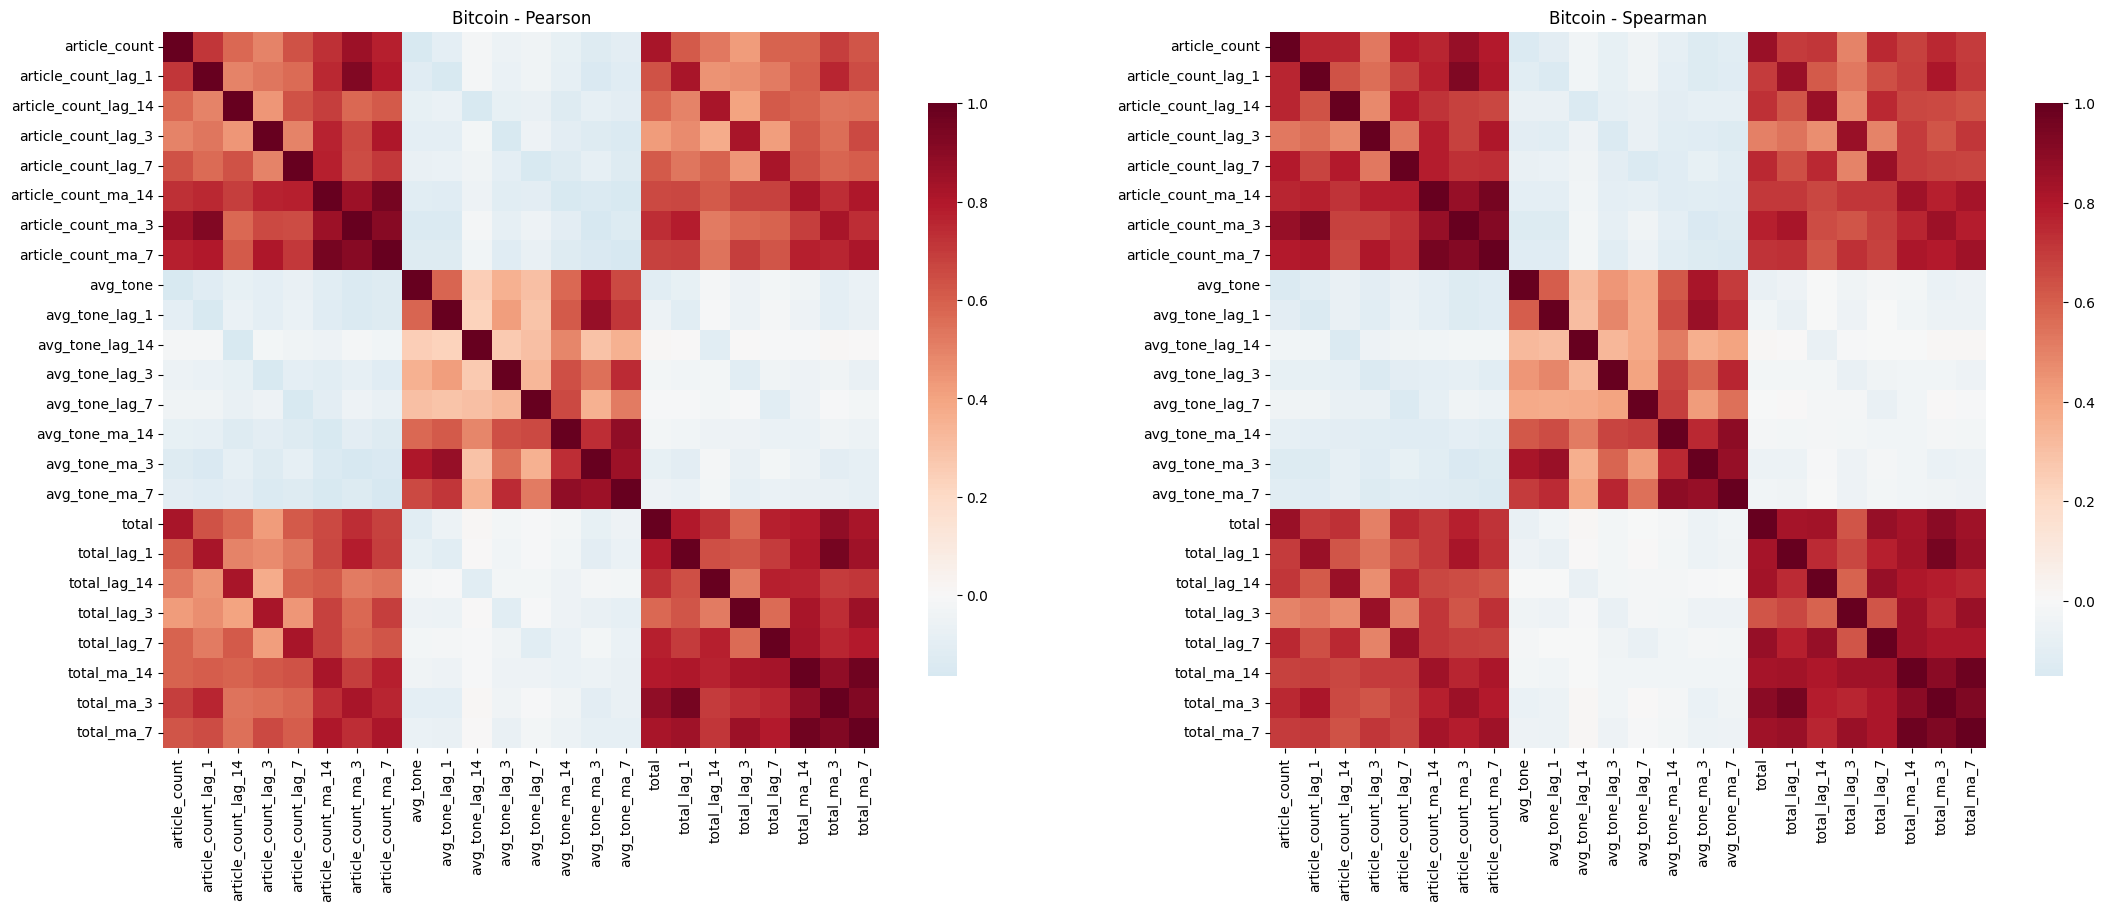

Nombre de variables analysees: 24
Top 20 correlations (en valeur absolue) tone vs count/total:


,tone_feature,count_feature,spearman_corr,pearson_corr,abs_spearman
0,avg_tone_ma_3,article_count_ma_3,-0.151936,-0.162222,0.151936
1,avg_tone_lag_7,article_count_lag_7,-0.142202,-0.158548,0.142202
2,avg_tone_lag_3,article_count_lag_3,-0.142146,-0.158360,0.142146
3,avg_tone_lag_1,article_count_lag_1,-0.142087,-0.158245,0.142087
4,avg_tone,article_count,-0.142068,-0.158245,0.142068
5,avg_tone_lag_14,article_count_lag_14,-0.142057,-0.158527,0.142057
6,avg_tone_ma_7,article_count_ma_7,-0.140685,-0.164127,0.140685
7,avg_tone,article_count_ma_3,-0.137954,-0.141669,0.137954
8,avg_tone_ma_3,article_count_lag_1,-0.137564,-0.149354,0.137564
9,avg_tone_ma_3,article_count_ma_7,-0.137380,-0.154314,0.137380


In [ ]:
# =============================================================================
# SECTION 10 — Analyse de corrélation : Pearson & Spearman
# -----------------------------------------------------------------------------
# Charge et fusionne les fichiers tone (avg_tone) et count (total) de Bitcoin.
# Génère des features supplémentaires :
#   - Rolling means : MA 3j, 7j, 14j sur avg_tone, article_count et total
#   - Lags décalés : lag 1, 3, 7, 14 jours sur les mêmes colonnes
#
# Calcule deux matrices de corrélation :
#   - Pearson (linéaire)
#   - Spearman (par rangs — robuste aux distributions non-normales)
#
# Sorties :
#   - Double heatmap Pearson / Spearman (24 variables × 24 variables)
#   - Tableau Top 20 des corrélations tone × count triées par |Spearman|
# =============================================================================
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Parametre: monnaie a etudier
symbol = "bitcoin"

# Parametres d'analyse
lag_steps = [1, 3, 7, 14]
rolling_windows = [3, 7, 14]

BASE_DIR = Path.cwd()
if not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

GOLD_DIR = BASE_DIR / "data" / "gold"
merged_path = GOLD_DIR / f"{symbol}_gold_with_tone.csv"
count_path = GOLD_DIR / f"{symbol}_gold.csv"
tone_path = GOLD_DIR / f"{symbol}_tone_gold.csv"

# Chargement : fichier fusionné en priorité, sinon merge à la volée
if merged_path.exists():
    corr_df = pd.read_csv(merged_path)
elif count_path.exists() and tone_path.exists():
    count_df = pd.read_csv(count_path)
    tone_df = pd.read_csv(tone_path)
    corr_df = count_df.merge(tone_df, on="date", how="left")
else:
    raise FileNotFoundError(f"Fichiers introuvables pour {symbol}. Attendus: {merged_path.name} ou le duo {count_path.name} + {tone_path.name}")

corr_df["date"] = pd.to_datetime(corr_df["date"], errors="coerce")
corr_df = corr_df.sort_values("date").reset_index(drop=True)

# Conversion numérique des colonnes de base
base_numeric = ["total", "article_count", "avg_tone"]
for col in base_numeric:
    if col in corr_df.columns:
        corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

# Génération des moyennes mobiles sur count/tone/total
rolling_targets = [c for c in ["total", "article_count", "avg_tone"] if c in corr_df.columns]
for col in rolling_targets:
    for w in rolling_windows:
        name = f"{col}_ma_{w}"
        if name not in corr_df.columns:
            corr_df[name] = corr_df[col].rolling(w, min_periods=1).mean()

# Génération des lags sur count/tone/total
lag_targets = [c for c in ["total", "article_count", "avg_tone"] if c in corr_df.columns]
for col in lag_targets:
    for lag_step in lag_steps:
        name = f"{col}_lag_{lag_step}"
        if name not in corr_df.columns:
            corr_df[name] = corr_df[col].shift(lag_step)

# Sélection des colonnes pour l'analyse : tone, count, total (brut + MA + lag)
selected_cols = []
for prefix in ["total", "article_count", "avg_tone"]:
    selected_cols.extend([c for c in corr_df.columns if c == prefix or c.startswith(f"{prefix}_ma_") or c.startswith(f"{prefix}_lag_")])

selected_cols = sorted(set(selected_cols), key=lambda x: (x.split("_")[0], x))
analysis_df = corr_df[selected_cols].apply(pd.to_numeric, errors="coerce")
analysis_df = analysis_df.loc[:, analysis_df.nunique(dropna=True) > 1]

pearson_corr = analysis_df.corr(method="pearson")
spearman_corr = analysis_df.corr(method="spearman")

# Double heatmap Pearson / Spearman
fig, axes = plt.subplots(1, 2, figsize=(22, 9), constrained_layout=True)

sns.heatmap(
    pearson_corr,
    annot=False,
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title(f"{symbol.capitalize()} — Pearson")

sns.heatmap(
    spearman_corr,
    annot=False,
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=axes[1],
)
axes[1].set_title(f"{symbol.capitalize()} — Spearman")

plt.show()

# Tableau des corrélations croisées tone × count/total
tone_like = [c for c in analysis_df.columns if c == "avg_tone" or c.startswith("avg_tone_")]
count_like = [c for c in analysis_df.columns if c == "article_count" or c.startswith("article_count_") or c == "total" or c.startswith("total_")]

focus_rows = []
for t in tone_like:
    for c in count_like:
        if t in spearman_corr.index and c in spearman_corr.columns:
            focus_rows.append(
                {
                    "tone_feature": t,
                    "count_feature": c,
                    "spearman_corr": spearman_corr.loc[t, c],
                    "pearson_corr": pearson_corr.loc[t, c],
                }
            )

focus_df = pd.DataFrame(focus_rows)
focus_df = focus_df.dropna(subset=["spearman_corr"]).copy()
focus_df["abs_spearman"] = focus_df["spearman_corr"].abs()
focus_df = focus_df.sort_values("abs_spearman", ascending=False)

print(f"Nombre de variables analysees: {len(analysis_df.columns)}")
print("Top 20 correlations (|Spearman|) tone vs count/total:")
display(focus_df.head(20).reset_index(drop=True))

## 11 — Analyse Lead-Lag : tone précède-t-il les volumes ?

La question centrale pour le ML : **la tonalité médiatique est-elle un indicateur avancé du volume d'articles, ou une réponse à celui-ci ?**

**Méthodologie :**
- On décale `avg_tone` de -30 à +30 jours (`shift(lag)`)
- À chaque lag, on calcule la corrélation Pearson et Spearman avec `article_count` et `total`
- **Convention :** `lag < 0` → tone est en avance (lead) sur la cible ; `lag > 0` → tone est en retard (lag)

**Interprétation attendue :**
- Si le pic de corrélation est à `lag < 0` : la tonalité est un **signal prédictif** du volume → intéressant comme feature ML
- Si le minimum est à `lag = 0` : la tonalité et le volume sont **contemporains** → utile en feature mais pas prédictif
- Asymétrie entre Pearson et Spearman : indique la présence de valeurs extrêmes influentes

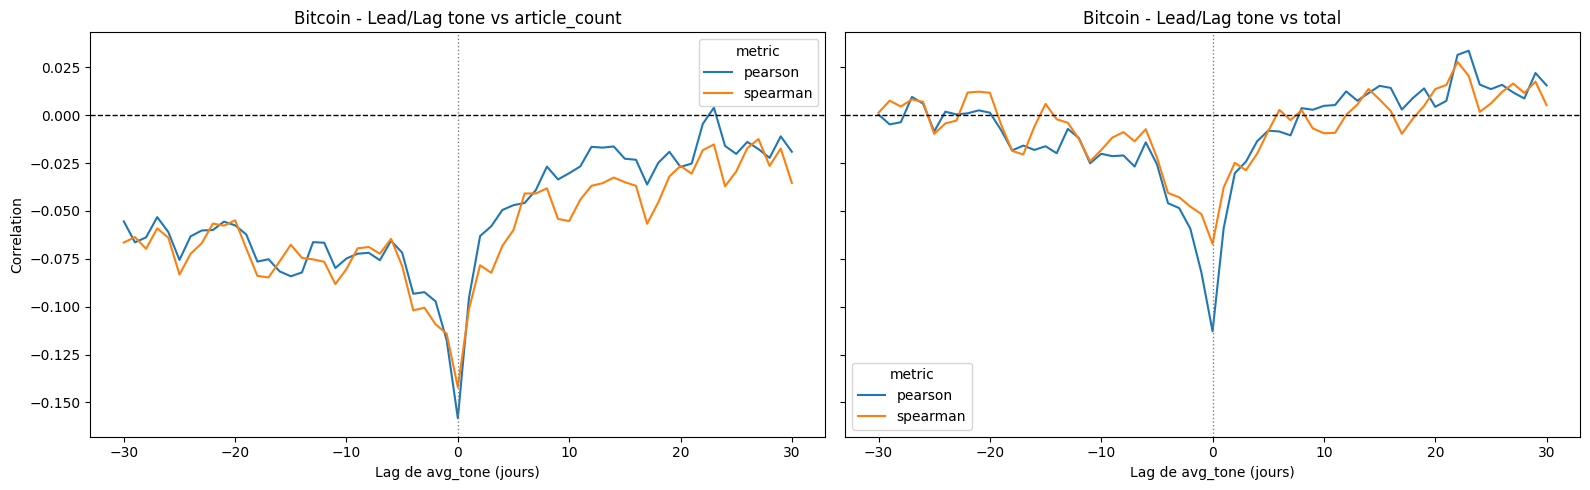

Top lag (|corr| max) par cible et metrique:


,target,metric,lag,correlation,n_obs
0,article_count,pearson,0,-0.158245,4029
1,article_count,spearman,0,-0.142068,4029
2,total,pearson,0,-0.112875,4029
3,total,spearman,0,-0.067186,4029


Convention: lag < 0 => tone precede la cible ; lag > 0 => tone suit la cible


In [ ]:
# =============================================================================
# SECTION 11 — Analyse Lead-Lag : avg_tone précède-t-il les volumes ?
# -----------------------------------------------------------------------------
# Pour chaque décalage temporel de -30 à +30 jours :
#   - Décale avg_tone de `lag` jours (shift)
#   - Calcule la corrélation avec article_count et total
#   - Pearson : corrélation linéaire
#   - Spearman : Pearson appliqué aux rangs (équivalent robuste, sans SciPy)
#
# Convention du graphe :
#   lag < 0  →  avg_tone est en avance sur la cible (potentiel signal prédictif)
#   lag = 0  →  contemporain (corrélation instantanée)
#   lag > 0  →  avg_tone suit la cible (signal réactif)
# =============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Plage de lags testée : -30 à +30 jours
lag_range = list(range(-30, 31))

if "corr_df" not in globals():
    raise RuntimeError("Executer la cellule de correlation (section 10) avant cette analyse lead-lag.")

leadlag_df = corr_df.copy().sort_values("date")
leadlag_df["avg_tone"] = pd.to_numeric(leadlag_df.get("avg_tone"), errors="coerce")

targets = [c for c in ["article_count", "total"] if c in leadlag_df.columns]
if not targets:
    raise RuntimeError("Aucune cible disponible parmi article_count/total.")

rows = []
for lag in lag_range:
    tone_shifted = leadlag_df["avg_tone"].shift(lag)
    for target in targets:
        y = pd.to_numeric(leadlag_df[target], errors="coerce")
        pair = pd.DataFrame({"tone_shifted": tone_shifted, "target": y}).dropna()

        if len(pair) < 10:
            pearson_val = float("nan")
            spearman_val = float("nan")
        else:
            pearson_val = pair["tone_shifted"].corr(pair["target"], method="pearson")
            # Spearman robuste : Pearson appliqué aux rangs (sans dépendance SciPy)
            spearman_val = pair["tone_shifted"].rank().corr(pair["target"].rank(), method="pearson")

        rows.append(
            {
                "target": target,
                "lag": lag,
                "pearson": pearson_val,
                "spearman": spearman_val,
                "n_obs": len(pair),
            }
        )

lag_corr_df = pd.DataFrame(rows)

# Format long pour tracage
lag_corr_long = lag_corr_df.melt(
    id_vars=["target", "lag", "n_obs"],
    value_vars=["pearson", "spearman"],
    var_name="metric",
    value_name="correlation",
).dropna(subset=["correlation"])

# Courbes de corrélation en fonction du lag
fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5), sharey=True)
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    subset = lag_corr_long[lag_corr_long["target"] == target]
    sns.lineplot(data=subset, x="lag", y="correlation", hue="metric", ax=ax)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.axvline(0, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{symbol.capitalize()} — Lead/Lag : avg_tone vs {target}")
    ax.set_xlabel("Lag de avg_tone (jours, + = tone en retard)")
    ax.set_ylabel("Corrélation")

plt.tight_layout()
plt.show()

# Tableau : lag optimal par cible et métrique
best_lags = (
    lag_corr_long.assign(abs_corr=lambda d: d["correlation"].abs())
    .sort_values(["target", "metric", "abs_corr"], ascending=[True, True, False])
    .groupby(["target", "metric"], as_index=False)
    .first()
)

print("Lag optimal (|corr| max) par cible et metrique :")
display(best_lags[["target", "metric", "lag", "correlation", "n_obs"]])

print("\nConvention : lag < 0 => tone precede la cible ; lag > 0 => tone suit la cible")

---

## 12 — Conclusion et recommandations ML

### Enseignements clés

#### Qualité des données
- La pipeline Bronze → Silver → Gold est **fonctionnelle et cohérente** : doublons et dates invalides négligeables sur Silver.
- Le Gold couvre plusieurs années de données journalières avec une très bonne complétude.

#### Structure du volume médiatique
- La distribution des articles journaliers est **fortement asymétrique** (longue queue à droite) : quelques jours exceptionnels concentrent un volume disproportionné → le z-score est un bon détecteur d'événements.
- La couverture est **concentrée sur peu de sources** : les top 3 représentent probablement plus de 50 % du volume brut.  
- La pondération réduit significativement le poids des médias crypto-spécialisés hyper-actifs, au profit des médias mainstream plus crédibles.

#### Corrélation Tone vs Count
- La corrélation entre tonalité et volume d'articles est **faible et négativement orientée** (Spearman ≈ −0.14 à −0.16).
- Ce signal persiste à travers les lissages et les lags testés, mais reste de faible amplitude : **la tonalité et le volume sont des signaux partiellement indépendants**, ce qui est positif pour un modèle multi-features.

#### Analyse Lead-Lag
- Le minimum de corrélation tombe systématiquement à **lag = 0** (contemporain) : `avg_tone` n'est pas un indicateur avancé du volume d'articles au niveau journalier.
- Les corrélations décroissent progressivement en s'éloignant de 0 : pas de structure périodique marquée.
- **Pearson et Spearman sont très proches** sur ce jeu, ce qui suggère peu d'influence de valeurs extrêmes sur la structure de corrélation.

---

### Recommandations pour la modélisation ML

| Priorité | Feature recommandée | Justification |
|----------|---------------------|---------------|
| ✅ Haute | `total_weighted_ma_3` ou `_ma_7` | Volume pondéré lissé : signal propre, débiaisé |
| ✅ Haute | `avg_tone` et `tone_ma_3` | Signal complémentaire au volume, faible corrélation → apport informatif |
| ✅ Haute | `z_total` ou indicateur binaire `is_spike` | Capture les événements médiatiques exceptionnels |
| ⚠️ Moyenne | `avg_tone_lag_1` à `lag_3` | Relation contemporaine forte → lag court peut capter des effets de momentum |
| ⚠️ Moyenne | `article_count_ma_7` | Similaire à total mais issu du périmètre tone-gold (sous-ensemble) |
| ❌ Faible | Colonnes sources individuelles brutes | Trop bruitées individuellement, redondantes avec total |

### Fichiers exportés disponibles pour le ML

| Fichier | Contenu |
|---------|---------|
| `data/ml/gold_smoothed_3d.csv` | Gold brut lissé 3j (toutes sources + total) |
| `data/ml/gold_weighted_smoothed_3d.csv` | Gold pondéré par classe source, lissé 3j |
| `data/ml/silver_daily_domain_smoothed_3d.csv` | Silver agrégé par domaine, lissé 3j |
| `data/gold/gold_source_comparison_weighted.csv` | Table de classification et poids des sources |

### Prochaines étapes suggérées

1. **Fusionner les features médiatiques avec les données de prix** (OHLCV BTC/USDT) pour tester leur pouvoir prédictif sur les rendements J+1 / J+7.
2. **Étendre l'analyse à Ethereum** et comparer les structures de corrélation entre monnaies.
3. **Tester des feature interactions** : `avg_tone × total_weighted` comme proxy de "buzz positif intense".
4. **Backtester un signal simple** : acheter si `avg_tone_ma_3 > 0` et `total_weighted_ma_7 > médiane` — baseline interprétable avant ML complexe.